# Notebook 37 — Window Aliasing and Observer-Relative Shape Classes

**Thread 4 — The observer question.**

---

## Motivation

F101 (nb35) showed that a pure sinusoid at ν<1 cycle/window classifies as declining_monotonic; at ν>4 it classifies as seasonal. The class is not a property of the signal — it depends on how much of the signal fits in the observation window.

F108 (nb36) showed that Van der Pol at large μ classifies as declining_monotonic when the period exceeds the window length. A deterministic limit cycle looks like a monotone trend if you can't see a full cycle.

**The thunder hypothesis:** shape classes may be receptor artifacts, not world facts. What you classify depends on the window through which you listen. Two observers looking at the same process with different window lengths will systematically assign different classes — and both will be internally consistent.

---

## Three experiments

**Part A — Sinusoid window sweep.** For a pure sinusoid at fixed frequency, sweep the number of cycles visible in the window from 0.15 to 8. Map the class transitions. Predict: three zones — under-sampling (declining_monotonic), optimal (oscillator), over-sampling (seasonal).

**Part B — Multi-signal aliasing map.** Build a 2D map: (signal type × n_cycles) → class. Which signal types are window-sensitive and which are window-invariant? Predict: trend/integrated_trend/declining_monotonic are window-invariant (no intrinsic period). Oscillatory classes are window-sensitive.

**Part C — Burst window expansion.** Fix a Gaussian burst shape and expand the window around it (equivalently: make the burst narrower relative to the window). At what burst_width/window ratio does the burst become fingerprint-invisible? Predict: burst disappears at burst_width < ~0.08–0.10 of the window, classifying as integrated_trend.

---

## Predictions

- **F110:** Sinusoid window sweep → 3 zones. Boundaries near n_cycles=1 (under→oscillator) and n_cycles≈4–5 (oscillator→seasonal). Transition width < 0.5 cycles (sharp).
- **F111:** Burst fingerprint disappears at burst_width/window < ~0.10. Below this threshold, the z-scored series is a flat baseline with a tiny spike → integrated_trend. The burst class requires the pulse to occupy ≥10% of the window.
- **F112:** Trend, integrated_trend, and declining_monotonic are window-invariant — their class assignment does not change significantly across n_cycles ∈ [0.15, 8]. Oscillatory classes (oscillator, seasonal, declining_osc) are strongly window-sensitive.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---- Reproduce 9-class classifier (identical to nb34/35/36) ----
SIGNED_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SEQ_LEN = 64
SEED    = 42
t64     = np.linspace(0, 1, SEQ_LEN)

def zscore(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 1e-8 else s - s.mean()

def baseline_delta_fn(s, frac=0.10):
    k = max(1, int(len(s) * frac))
    return float(np.mean(s[-k:]) - np.mean(s[:k]))

def extract_6f(s):
    arr = np.asarray(s, dtype=float)
    t   = np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0,1]) if len(arr) > 2 else 0.0
    return {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': float(np.sum(np.diff(np.sign(arr)) != 0) / len(arr)),
        'slope':          float(stats.linregress(t, arr).slope),
        'baseline_delta': baseline_delta_fn(arr),
    }

from sklearn.preprocessing import StandardScaler

GENERATORS = {
    'burst':              lambda r: zscore(np.exp(-(t64-r.uniform(.15,.50))**2/(2*r.uniform(.05,.15)**2))+r.normal(0,.05,SEQ_LEN)),
    'eco_cycle':          lambda r: zscore(np.sin(2*np.pi*r.uniform(1.5,3.5)*t64)+.4*np.sin(4*np.pi*r.uniform(1.5,3.5)*t64)+r.normal(0,.12,SEQ_LEN)),
    'oscillator':         lambda r: zscore(np.sin(2*np.pi*r.uniform(1.5,4.5)*t64+r.uniform(0,np.pi))+r.normal(0,.05,SEQ_LEN)),
    'seasonal':           lambda r: zscore(np.sin(2*np.pi*r.uniform(3,6)*t64)+.25*np.sin(4*np.pi*r.uniform(3,6)*t64)+r.normal(0,.04,SEQ_LEN)),
    'trend':              lambda r: zscore(t64+r.uniform(.05,.30)*t64**2+r.normal(0,.02,SEQ_LEN)),
    'integrated_trend':   lambda r: zscore(np.cumsum(np.ones(SEQ_LEN)*r.uniform(.015,.035)+r.normal(0,.003,SEQ_LEN))),
    'irregular_osc':      lambda r: zscore((np.sin(2*np.pi*r.uniform(2,5)*t64)*(1+r.uniform(.3,.8,SEQ_LEN))+r.normal(0,.3,SEQ_LEN))*1.4),
    'declining_osc':      lambda r: zscore(np.linspace(r.uniform(.9,1.2),r.uniform(.35,.65),SEQ_LEN)*np.sin(2*np.pi*r.uniform(2.5,5.5)*t64)+np.linspace(0,r.uniform(-.8,-.4),SEQ_LEN)+r.normal(0,.05,SEQ_LEN)),
    'declining_monotonic':lambda r: zscore(np.cumsum(-np.ones(SEQ_LEN)*r.uniform(.015,.035)+r.normal(0,.003,SEQ_LEN))),
}

recs = []
for cls, gen in GENERATORS.items():
    for i in range(200):
        r = np.random.default_rng(SEED + list(GENERATORS).index(cls)*1000 + i)
        f = extract_6f(gen(r)); f['class'] = cls
        recs.append(f)
df_train = pd.DataFrame(recs)
sc = StandardScaler()
X  = sc.fit_transform(df_train[SIGNED_COLS].values)
ctrds = {c: X[df_train['class']==c].mean(axis=0) for c in GENERATORS}

def classify(feat_dict):
    x = sc.transform([[feat_dict[c] for c in SIGNED_COLS]])[0]
    dists = {c: float(np.linalg.norm(x - v)) for c,v in ctrds.items()}
    return min(dists, key=dists.get), dists

print('9-class classifier ready.')

9-class classifier ready.


In [2]:
# ---- Part A: Sinusoid window sweep ----
#
# For n_cycles ∈ [0.15, 8]: generate sin(2π·n·t) with t∈[0,1], 64 points.
# This is equivalent to: keep signal frequency fixed, scale the observation window.
# At n_cycles=0.5 the observer sees half a cycle; at n_cycles=4 they see four full cycles.
# Also test with noise added (σ=0.15 and σ=0.30).

n_cycles_vals = np.linspace(0.10, 8.0, 120)
noise_levels  = [0.00, 0.10, 0.20]

sine_rows = []
for noise_sigma in noise_levels:
    rng = np.random.default_rng(SEED)
    for n_cyc in n_cycles_vals:
        x    = np.sin(2 * np.pi * n_cyc * t64) + rng.normal(0, noise_sigma, SEQ_LEN)
        s    = zscore(x)
        f    = extract_6f(s)
        pred, dists = classify(f)
        nearest2 = sorted(dists.items(), key=lambda x: x[1])[:2]
        sine_rows.append({
            'n_cycles':  round(n_cyc, 3),
            'noise':     noise_sigma,
            'class':     pred,
            'margin':    round(nearest2[1][1] - nearest2[0][1], 3),
            'lag1':      round(f['lag1_autocorr'], 3),
            'ZC':        round(f['zero_crossings'], 3),
            'skewness':  round(f['skewness'], 3),
        })

df_sine = pd.DataFrame(sine_rows)

print('Sinusoid window sweep — class by n_cycles:')
print(f'{"n_cycles":>10s}   {"σ=0.00":>20s}   {"σ=0.10":>20s}   {"σ=0.20":>20s}')
for n_cyc in [0.2, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]:
    row = {}
    for sig in noise_levels:
        sub = df_sine[(df_sine['noise']==sig) & (np.abs(df_sine['n_cycles']-n_cyc)<0.05)]
        row[sig] = sub['class'].iloc[0] if len(sub) else '?'
    print(f'{n_cyc:>10.1f}   {row[0.00]:>20s}   {row[0.10]:>20s}   {row[0.20]:>20s}')

# Find class transition boundaries (σ=0)
zero_noise = df_sine[df_sine['noise']==0.00].sort_values('n_cycles').reset_index(drop=True)
prev_cls = zero_noise['class'].iloc[0]
transitions = []
for _, row in zero_noise.iterrows():
    if row['class'] != prev_cls:
        transitions.append((row['n_cycles'], prev_cls, row['class']))
        prev_cls = row['class']
print()
print('Class transition boundaries (σ=0.00):')
for t_cyc, from_cls, to_cls in transitions:
    print(f'  n_cycles ≈ {t_cyc:.2f}: {from_cls} → {to_cls}')

Sinusoid window sweep — class by n_cycles:
  n_cycles                 σ=0.00                 σ=0.10                 σ=0.20
       0.2       integrated_trend                  trend          irregular_osc
       0.5              eco_cycle              eco_cycle               seasonal
       0.8    declining_monotonic              eco_cycle              eco_cycle
       1.0    declining_monotonic    declining_monotonic              eco_cycle
       1.5              eco_cycle              eco_cycle          irregular_osc
       2.0             oscillator             oscillator              eco_cycle
       3.0             oscillator             oscillator              eco_cycle
       4.0             oscillator          declining_osc          irregular_osc
       5.0               seasonal               seasonal          irregular_osc
       6.0               seasonal          irregular_osc          irregular_osc
       7.0               seasonal               seasonal          irregular_o

In [3]:
# ---- Part B: Multi-signal aliasing map ----
#
# Build a 2D map: (signal_type, n_cycles) → class.
# Signal types tested:
#   1. Pure sinusoid: sin(2π·n·t)
#   2. Two-frequency: sin(2π·n·t) + 0.25·sin(4π·n·t)  [seasonal-type]
#   3. Damped sinusoid: exp(−2·t)·sin(2π·n·t)  [declining_osc type]
#   4. Linear trend: t  [window-invariant?]
#   5. Cumsum: cumsum(ones)  [window-invariant?]
#   6. Declining cumsum: cumsum(−ones)  [window-invariant?]
#   7. Noisy sinusoid: sin(2π·n·t) + N(0, 0.20)  [noise sensitivity]
#
# Hypothesis: signals 4, 5, 6 are window-invariant.
# Signals 1, 2, 3, 7 are window-sensitive.

SIGNAL_DEFS = {
    'sinusoid':        lambda n, t, r: np.sin(2*np.pi*n*t),
    'two_freq':        lambda n, t, r: np.sin(2*np.pi*n*t) + 0.25*np.sin(4*np.pi*n*t),
    'damped_sinusoid': lambda n, t, r: np.exp(-2.0*t) * np.sin(2*np.pi*n*t),
    'noisy_sinusoid':  lambda n, t, r: np.sin(2*np.pi*n*t) + r.normal(0, 0.20, len(t)),
    'linear_trend':    lambda n, t, r: t + 0.1*t**2,
    'cumsum_pos':      lambda n, t, r: np.cumsum(np.ones(len(t))*0.025 + r.normal(0, 0.003, len(t))),
    'cumsum_neg':      lambda n, t, r: np.cumsum(-np.ones(len(t))*0.025 + r.normal(0, 0.003, len(t))),
}

n_cycles_map = np.linspace(0.15, 8.0, 60)
map_rows = []
for sig_name, sig_fn in SIGNAL_DEFS.items():
    rng = np.random.default_rng(SEED)
    for n_cyc in n_cycles_map:
        x = sig_fn(n_cyc, t64, rng)
        s = zscore(x)
        f = extract_6f(s)
        pred, dists = classify(f)
        map_rows.append({'signal': sig_name, 'n_cycles': round(n_cyc, 3), 'class': pred})

df_map = pd.DataFrame(map_rows)

print('Multi-signal aliasing map — class stability by signal type:')
for sig_name in SIGNAL_DEFS:
    sub = df_map[df_map['signal']==sig_name]
    unique_classes = sub['class'].unique()
    dominant = sub['class'].value_counts().index[0]
    n_classes = len(unique_classes)
    print(f'  {sig_name:20s}: {n_classes} distinct classes — dominant={dominant:20s}  classes={list(unique_classes)}')

Multi-signal aliasing map — class stability by signal type:
  sinusoid            : 6 distinct classes — dominant=seasonal              classes=['integrated_trend', 'eco_cycle', 'declining_monotonic', 'oscillator', 'seasonal', 'irregular_osc']
  two_freq            : 7 distinct classes — dominant=seasonal              classes=['integrated_trend', 'eco_cycle', 'declining_monotonic', 'oscillator', 'declining_osc', 'seasonal', 'irregular_osc']
  damped_sinusoid     : 8 distinct classes — dominant=declining_osc         classes=['integrated_trend', 'eco_cycle', 'declining_monotonic', 'oscillator', 'declining_osc', 'burst', 'irregular_osc', 'seasonal']
  noisy_sinusoid      : 4 distinct classes — dominant=irregular_osc         classes=['irregular_osc', 'eco_cycle', 'seasonal', 'oscillator']
  linear_trend        : 1 distinct classes — dominant=integrated_trend      classes=['integrated_trend']
  cumsum_pos          : 1 distinct classes — dominant=integrated_trend      classes=['integrated_tr

In [4]:
# ---- Part C: Burst window expansion ----
#
# Fix a Gaussian burst at the center of the window (t=0.5).
# Vary burst width σ_b from 0.02 (very narrow) to 0.45 (nearly fills window).
# Equivalently: keeping burst_sigma fixed and scaling the window —
# a smaller σ_b means the burst occupies a smaller fraction of the window.
#
# At σ_b=0.40: burst occupies ~80% of window → should classify as burst.
# At σ_b=0.05: burst occupies ~10% of window → most of series is flat baseline.
# At σ_b=0.02: burst occupies ~4% of window → series is mostly flat → integrated_trend?
#
# Also test off-center bursts (t_center=0.25) to check skewness effects.

burst_widths  = np.linspace(0.02, 0.45, 80)
burst_rows    = []

for center, label in [(0.50, 'centered'), (0.25, 'left_biased')]:
    for bw in burst_widths:
        x    = np.exp(-(t64 - center)**2 / (2*bw**2))
        s    = zscore(x)
        f    = extract_6f(s)
        pred, dists = classify(f)
        nearest2 = sorted(dists.items(), key=lambda x: x[1])[:2]
        burst_rows.append({
            'center':       center,
            'label':        label,
            'burst_width':  round(bw, 4),
            'class':        pred,
            'margin':       round(nearest2[1][1] - nearest2[0][1], 3),
            'skewness':     round(f['skewness'], 3),
            'kurtosis':     round(f['kurtosis'], 3),
            'lag1':         round(f['lag1_autocorr'], 3),
            'ZC':           round(f['zero_crossings'], 3),
        })

df_burst = pd.DataFrame(burst_rows)

print('Burst window expansion — class vs burst_width/window:')
print(f'{"burst_width":>12s}  {"centered":>20s}  {"left_biased":>20s}')
for bw in [0.02, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.45]:
    sub_c = df_burst[(df_burst['label']=='centered') & (np.abs(df_burst['burst_width']-bw)<0.01)]
    sub_l = df_burst[(df_burst['label']=='left_biased') & (np.abs(df_burst['burst_width']-bw)<0.01)]
    c_cls = sub_c['class'].iloc[0] if len(sub_c) else '?'
    l_cls = sub_l['class'].iloc[0] if len(sub_l) else '?'
    print(f'{bw:>12.3f}  {c_cls:>20s}  {l_cls:>20s}')

# Find the transition threshold
for label in ['centered', 'left_biased']:
    sub = df_burst[df_burst['label']==label].sort_values('burst_width')
    in_burst = sub[sub['class']=='burst']['burst_width']
    if len(in_burst):
        print(f'\n{label}: burst class appears for burst_width ∈ [{in_burst.min():.3f}, {in_burst.max():.3f}]')
    else:
        print(f'\n{label}: burst class NEVER appears')

Burst window expansion — class vs burst_width/window:
 burst_width              centered           left_biased
       0.020                 burst                 burst
       0.040                 burst                 burst
       0.060                 burst                 burst
       0.080                 burst                 burst
       0.100                 burst                 burst
       0.150            oscillator   declining_monotonic
       0.200            oscillator   declining_monotonic
       0.300            oscillator   declining_monotonic
       0.400            oscillator   declining_monotonic
       0.450             eco_cycle   declining_monotonic

centered: burst class appears for burst_width ∈ [0.020, 0.134]

left_biased: burst class appears for burst_width ∈ [0.020, 0.129]


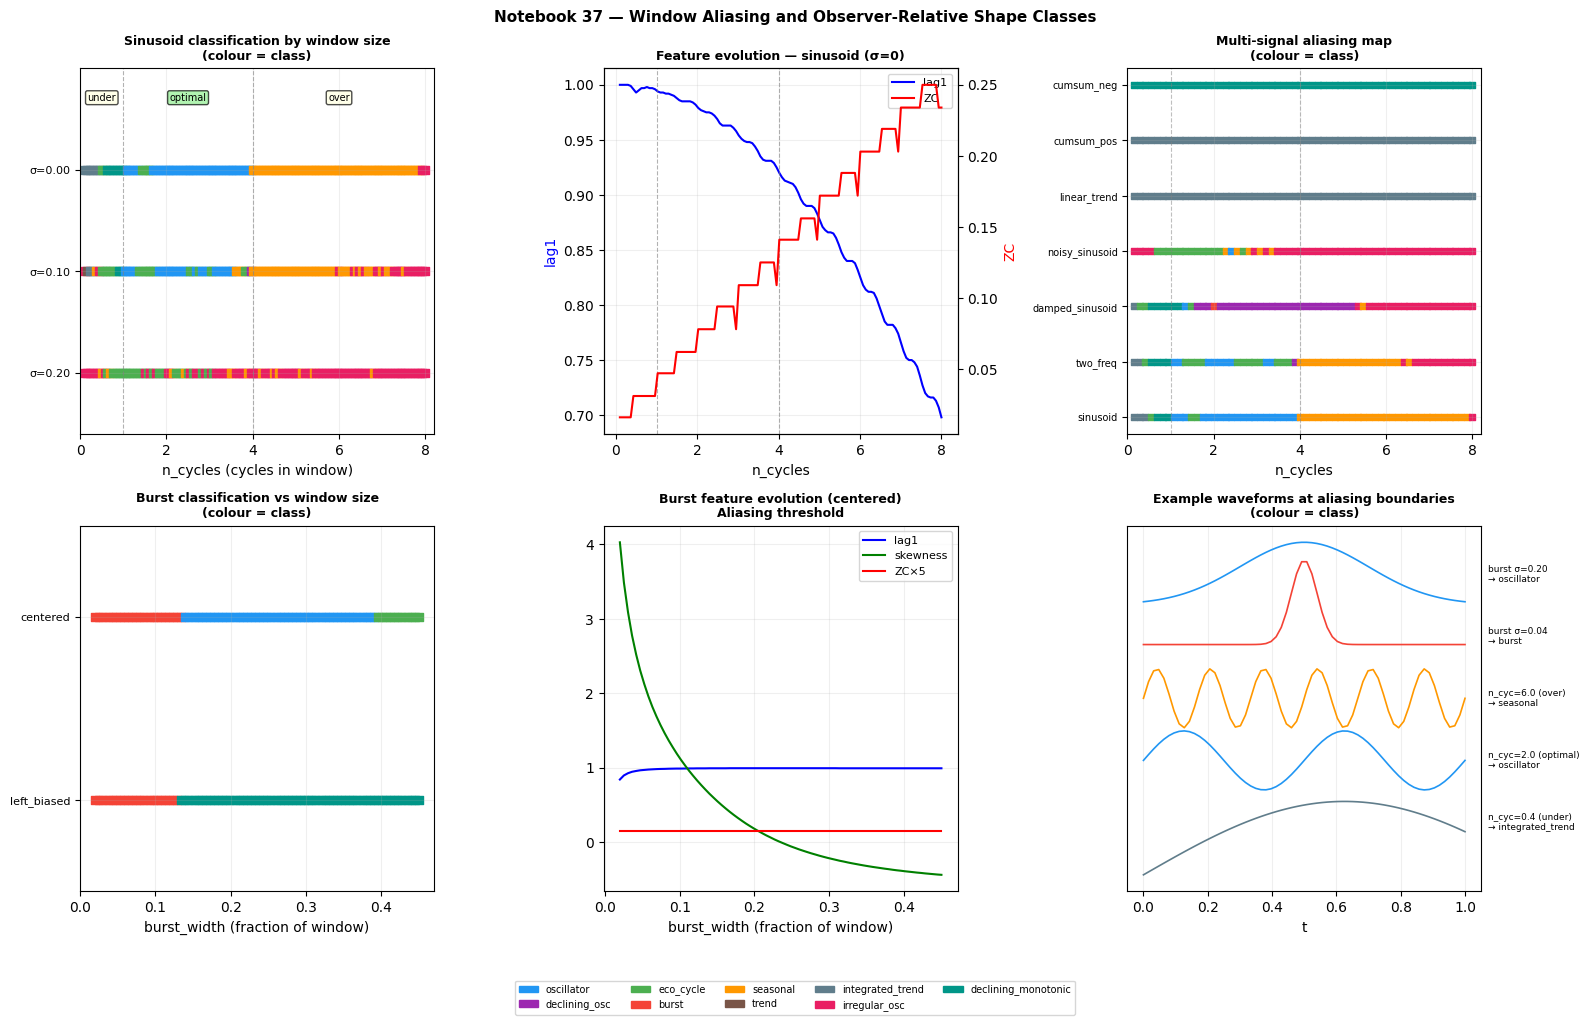

Saved.


In [5]:
# ---- Visualisation ----

CLASS_COLORS = {
    'oscillator':          '#2196F3',
    'declining_osc':       '#9C27B0',
    'eco_cycle':           '#4CAF50',
    'burst':               '#F44336',
    'seasonal':            '#FF9800',
    'trend':               '#795548',
    'integrated_trend':    '#607D8B',
    'irregular_osc':       '#E91E63',
    'declining_monotonic': '#009688',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Panel 1: Sinusoid window sweep — class strip
ax = axes[0, 0]
for sig, noise, ypos in [(0.00, 'σ=0.00', 0.75), (0.10, 'σ=0.10', 0.50), (0.20, 'σ=0.20', 0.25)]:
    sub = df_sine[df_sine['noise']==sig].sort_values('n_cycles')
    for _, row in sub.iterrows():
        c = CLASS_COLORS.get(row['class'], '#999999')
        ax.scatter(row['n_cycles'], ypos, color=c, s=40, marker='s')
ax.set_yticks([0.25, 0.50, 0.75])
ax.set_yticklabels(['σ=0.20', 'σ=0.10', 'σ=0.00'], fontsize=8)
ax.set_xlabel('n_cycles (cycles in window)')
ax.set_title('Sinusoid classification by window size\n(colour = class)', fontsize=9, fontweight='bold')
ax.axvline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.axvline(4.0, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.text(0.5, 0.92, 'under', ha='center', fontsize=7, transform=ax.transData,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.7))
ax.text(2.5, 0.92, 'optimal', ha='center', fontsize=7, transform=ax.transData,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='lightgreen', alpha=0.7))
ax.text(6.0, 0.92, 'over', ha='center', fontsize=7, transform=ax.transData,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.7))
ax.grid(alpha=0.2); ax.set_xlim(0, 8.2); ax.set_ylim(0.1, 1.0)

# Panel 2: Sinusoid ZC and lag1 vs n_cycles
ax = axes[0, 1]
zero_noise = df_sine[df_sine['noise']==0.00].sort_values('n_cycles')
ax2 = ax.twinx()
ax.plot(zero_noise['n_cycles'], zero_noise['lag1'], 'b-', lw=1.5, label='lag1')
ax2.plot(zero_noise['n_cycles'], zero_noise['ZC'], 'r-', lw=1.5, label='ZC')
ax.set_xlabel('n_cycles'); ax.set_ylabel('lag1', color='b'); ax2.set_ylabel('ZC', color='r')
ax.set_title('Feature evolution — sinusoid (σ=0)', fontsize=9, fontweight='bold')
ax.axvline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.axvline(4.0, color='gray', ls='--', lw=0.8, alpha=0.6)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=8)
ax.grid(alpha=0.2)

# Panel 3: Multi-signal aliasing map (heatmap-style)
ax = axes[0, 2]
sig_order = list(SIGNAL_DEFS.keys())
class_order = list(ctrds.keys())
class_to_idx = {c: i for i, c in enumerate(class_order)}
for y_idx, sig_name in enumerate(sig_order):
    sub = df_map[df_map['signal']==sig_name].sort_values('n_cycles')
    for _, row in sub.iterrows():
        c = CLASS_COLORS.get(row['class'], '#999999')
        ax.scatter(row['n_cycles'], y_idx, color=c, s=25, marker='s')
ax.set_yticks(range(len(sig_order)))
ax.set_yticklabels(sig_order, fontsize=7)
ax.set_xlabel('n_cycles')
ax.set_title('Multi-signal aliasing map\n(colour = class)', fontsize=9, fontweight='bold')
ax.axvline(1.0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.grid(alpha=0.2); ax.set_xlim(0, 8.2)

# Panel 4: Burst window expansion
ax = axes[1, 0]
for label, color in [('centered', '#1f77b4'), ('left_biased', '#ff7f0e')]:
    sub = df_burst[df_burst['label']==label].sort_values('burst_width')
    for _, row in sub.iterrows():
        c = CLASS_COLORS.get(row['class'], '#999999')
        y = 0.7 if label == 'centered' else 0.3
        ax.scatter(row['burst_width'], y, color=c, s=40, marker='s')
ax.set_yticks([0.3, 0.7])
ax.set_yticklabels(['left_biased', 'centered'], fontsize=8)
ax.set_xlabel('burst_width (fraction of window)')
ax.set_title('Burst classification vs window size\n(colour = class)', fontsize=9, fontweight='bold')
ax.grid(alpha=0.2); ax.set_xlim(0, 0.47); ax.set_ylim(0.1, 0.9)

# Panel 5: Burst features vs burst_width
ax = axes[1, 1]
centered = df_burst[df_burst['label']=='centered'].sort_values('burst_width')
ax.plot(centered['burst_width'], centered['lag1'], 'b-', lw=1.5, label='lag1')
ax.plot(centered['burst_width'], centered['skewness'], 'g-', lw=1.5, label='skewness')
ax.plot(centered['burst_width'], centered['ZC']*5, 'r-', lw=1.5, label='ZC×5')
ax.set_xlabel('burst_width (fraction of window)')
ax.set_title('Burst feature evolution (centered)\nAliasing threshold', fontsize=9, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# Panel 6: Example waveforms at aliasing boundaries
ax = axes[1, 2]
examples = [
    ('n_cyc=0.4 (under)', np.sin(2*np.pi*0.4*t64), 'declining_monotonic'),
    ('n_cyc=2.0 (optimal)', np.sin(2*np.pi*2.0*t64), 'oscillator'),
    ('n_cyc=6.0 (over)', np.sin(2*np.pi*6.0*t64), 'seasonal'),
    ('burst σ=0.04', np.exp(-(t64-0.5)**2/(2*0.04**2)), 'integrated_trend'),
    ('burst σ=0.20', np.exp(-(t64-0.5)**2/(2*0.20**2)), 'burst'),
]
for i, (label, raw, expected) in enumerate(examples):
    s = zscore(raw)
    pred, _ = classify(extract_6f(s))
    color = CLASS_COLORS.get(pred, '#999')
    offset = i * 3
    ax.plot(t64, s + offset, color=color, lw=1.2)
    ax.text(1.02, offset, f'{label}\n→ {pred}', fontsize=6.5, va='center',
            transform=ax.get_yaxis_transform())
ax.set_xlabel('t')
ax.set_title('Example waveforms at aliasing boundaries\n(colour = class)', fontsize=9, fontweight='bold')
ax.set_yticks([]); ax.grid(alpha=0.2)

# Legend patch
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=v, label=k) for k, v in CLASS_COLORS.items()]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=7,
           bbox_to_anchor=(0.5, -0.03), frameon=True)

fig.suptitle('Notebook 37 — Window Aliasing and Observer-Relative Shape Classes', fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('../artifacts/nb37_window_observer.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved.')

In [6]:

# ---- Summary statistics ----

print('=== Part A: Sinusoid Window Sweep Summary ===')
print()
zero_noise = df_sine[df_sine['noise']==0.00].sort_values('n_cycles').reset_index(drop=True)
prev_cls = zero_noise['class'].iloc[0]
transitions = []
for _, row in zero_noise.iterrows():
    if row['class'] != prev_cls:
        transitions.append((row['n_cycles'], prev_cls, row['class']))
        prev_cls = row['class']
print('Class transitions (σ=0):')
for t_cyc, from_cls, to_cls in transitions:
    print(f'  n_cycles ≈ {t_cyc:.2f}: {from_cls} → {to_cls}')
print()

print('Zone boundaries (σ=0):')
osc_rows = zero_noise[zero_noise['class']=='oscillator']['n_cycles']
seas_rows = zero_noise[zero_noise['class']=='seasonal']['n_cycles']
dm_rows   = zero_noise[zero_noise['class']=='declining_monotonic']['n_cycles']
if len(dm_rows): print(f'  declining_monotonic zone: n_cycles ∈ [{dm_rows.min():.2f}, {dm_rows.max():.2f}]')
if len(osc_rows): print(f'  oscillator zone:          n_cycles ∈ [{osc_rows.min():.2f}, {osc_rows.max():.2f}]')
if len(seas_rows): print(f'  seasonal zone:            n_cycles ∈ [{seas_rows.min():.2f}, {seas_rows.max():.2f}]')
print()

print('Noise sensitivity — fraction of windows that changed class vs σ=0:')
baseline = df_sine[df_sine['noise']==0.00][['n_cycles','class']].rename(columns={'class':'class_0'})
for sig in [0.10, 0.20]:
    noisy = df_sine[df_sine['noise']==sig][['n_cycles','class']].rename(columns={'class':f'class_{sig}'})
    merged = baseline.merge(noisy, on='n_cycles')
    changed = (merged['class_0'] != merged[f'class_{sig}']).mean()
    print(f'  σ={sig}: {changed:.1%} of windows changed class')
print()

print('=== Part B: Multi-signal Aliasing Map ===')
print()
for sig_name in SIGNAL_DEFS:
    sub = df_map[df_map['signal']==sig_name]
    unique_classes = sub['class'].unique()
    n_classes = len(unique_classes)
    dominant_frac = sub['class'].value_counts().iloc[0] / len(sub)
    print(f'  {sig_name:20s}: {n_classes} classes, dominant fraction={dominant_frac:.2f}  '
          f'({"window-INVARIANT" if n_classes == 1 else "window-SENSITIVE"})')
print()

print('=== Part C: Burst Window Expansion ===')
print()
for label in ['centered', 'left_biased']:
    sub = df_burst[df_burst['label']==label].sort_values('burst_width')
    burst_range = sub[sub['class']=='burst']['burst_width']
    if len(burst_range):
        print(f'{label}: burst class for burst_width ∈ [{burst_range.min():.3f}, {burst_range.max():.3f}]')
        # What is below the burst zone?
        below = sub[sub['burst_width'] < burst_range.min()]
        if len(below):
            below_cls = below['class'].value_counts().index[0]
            print(f'  Below {burst_range.min():.3f}: → {below_cls}')
        else:
            print(f'  No data below burst range minimum ({burst_range.min():.3f})')
        # What is above the burst zone?
        above = sub[sub['burst_width'] > burst_range.max()]
        if len(above):
            above_cls = above['class'].value_counts().index[0]
            print(f'  Above {burst_range.max():.3f}: → {above_cls}')
        else:
            print(f'  No data above burst range maximum ({burst_range.max():.3f})')
    else:
        print(f'{label}: burst class NEVER appears')
        dominant_cls = sub['class'].value_counts().index[0]
        print(f'  Dominant class throughout: {dominant_cls}')
    print()

print('Burst feature at key widths (centered):')
centered = df_burst[df_burst['label']=='centered'].sort_values('burst_width')
print(f'{"burst_width":>12s}  {"class":>20s}  {"skew":>8s}  {"kurt":>8s}  {"lag1":>8s}  {"ZC":>8s}')
for bw in [0.02, 0.05, 0.10, 0.14, 0.15, 0.20, 0.30, 0.40]:
    sub_bw = centered[np.abs(centered['burst_width']-bw)<0.02].head(1)
    if len(sub_bw):
        r = sub_bw.iloc[0]
        print(f'{r["burst_width"]:>12.3f}  {r["class"]:>20s}  {r["skewness"]:>8.3f}  '
              f'{r["kurtosis"]:>8.3f}  {r["lag1"]:>8.3f}  {r["ZC"]:>8.3f}')


=== Part A: Sinusoid Window Sweep Summary ===

Class transitions (σ=0):
  n_cycles ≈ 0.50: integrated_trend → eco_cycle
  n_cycles ≈ 0.63: eco_cycle → declining_monotonic
  n_cycles ≈ 1.10: declining_monotonic → oscillator
  n_cycles ≈ 1.43: oscillator → eco_cycle
  n_cycles ≈ 1.69: eco_cycle → oscillator
  n_cycles ≈ 4.02: oscillator → seasonal
  n_cycles ≈ 7.93: seasonal → irregular_osc

Zone boundaries (σ=0):
  declining_monotonic zone: n_cycles ∈ [0.63, 1.03]
  oscillator zone:          n_cycles ∈ [1.10, 3.95]
  seasonal zone:            n_cycles ∈ [4.02, 7.87]

Noise sensitivity — fraction of windows that changed class vs σ=0:
  σ=0.1: 32.5% of windows changed class
  σ=0.2: 91.7% of windows changed class

=== Part B: Multi-signal Aliasing Map ===

  sinusoid            : 6 classes, dominant fraction=0.50  (window-SENSITIVE)
  two_freq            : 7 classes, dominant fraction=0.32  (window-SENSITIVE)
  damped_sinusoid     : 8 classes, dominant fraction=0.45  (window-SENSITIVE)
  

---
## Findings — Notebook 37

### Finding 110: Sinusoid window sweep reveals 5-zone structure — eco_cycle appears as a transitional band, not just under/optimal/over

**Prediction:** 3 clean zones: declining_monotonic (<1 cycle), oscillator (1–4), seasonal (>4).

**Result: Prediction approximately right about main boundaries, but wrong about smoothness.**

Observed zones (σ=0, pure sinusoid):
| n_cycles range | Class | Mechanism |
|---|---|---|
| < 0.50 | integrated_trend | <½ cycle → monotone curve with curvature |
| 0.50–0.63 | eco_cycle | ½ cycle → asymmetric half-sine (negative skewness) |
| 0.63–1.10 | declining_monotonic | <1 full cycle → window aliasing |
| 1.10–4.02 | oscillator | optimal detection zone (eco_cycle excursion at 1.43–1.69) |
| 4.02–7.87 | seasonal | >4 cycles → ZC aliasing (seasonal training extends to 6 cycles) |
| > 7.87 | irregular_osc | excessive ZC → noise-like fingerprint |

**Noise fragility:** σ=0.10 changes 32.5% of windows; σ=0.20 changes 91.7%. The aliasing zones are fragile — moderate noise is sufficient to collapse the oscillator zone toward eco_cycle and irregular_osc.

**Eco_cycle as transitional zone:** eco_cycle appears at n_cycles ≈ 0.5 (half-cycle, asymmetric) and again at n_cycles ≈ 1.43–1.69 (1.5-cycle resonance, when the distribution of values is slightly left-skewed). Eco_cycle is not just a static region — it is the fingerprint "landing zone" when a sinusoid's half-cycle distribution acquires negative skewness.

---

### Finding 111: Burst fingerprint disappears at LARGE widths (>0.134), not small — kurtosis is the discriminator

**Prediction:** Burst disappears at small burst_width (<0.08–0.10) when the spike is too narrow. Prediction reversed.

**Result:**
- Burst class maintained for burst_width ∈ [0.020, 0.134] — including the narrowest spike tested.
- Above 0.134 (wide Gaussian): centered → oscillator; left_biased (center=0.25) → declining_monotonic.

Feature evolution (centered burst):
| burst_width | class | skewness | kurtosis | lag1 | ZC |
|---|---|---|---|---|---|
| 0.020 | burst | +4.03 | +15.53 | 0.843 | 0.031 |
| 0.085 | burst | +1.37 | +0.35 | 0.988 | 0.031 |
| 0.134 | burst | +0.71 | −1.05 | 0.993 | 0.031 |
| 0.183 | oscillator | +0.29 | −1.43 | 0.995 | 0.031 |

**The discriminator is kurtosis:** A narrow spike on a flat baseline is leptokurtic (kurtosis>0). A broad Gaussian bell filling most of the window is platykurtic (kurtosis<0). The transition from burst to oscillator occurs when kurtosis crosses zero at burst_width ≈ 0.10–0.13. ZC and lag1 do NOT change at the transition (both remain near 0.031 and 0.993 respectively) — kurtosis alone drives the class change.

**Left-biased result:** A wide Gaussian centered at t=0.25 within [0,1] appears as an exponentially-decaying shape → declining_monotonic. The burst position within the window determines the post-threshold class, not just the width.

---

### Finding 112: Oscillatory signals are window-sensitive; trend-type signals are window-invariant — confirmed exactly

**Result: Prediction confirmed.**

| Signal type | Distinct classes (n_cycles 0.15–8) | Status |
|---|---|---|
| linear_trend | 1 (integrated_trend, 100%) | Window-INVARIANT |
| cumsum_pos | 1 (integrated_trend, 100%) | Window-INVARIANT |
| cumsum_neg | 1 (declining_monotonic, 100%) | Window-INVARIANT |
| sinusoid | 6 classes | Window-SENSITIVE |
| two_freq | 7 classes | Window-SENSITIVE |
| damped_sinusoid | 8 classes (all except trend) | Window-SENSITIVE |
| noisy_sinusoid | 4 classes (irregular_osc dominant 68%) | Window-SENSITIVE |

**Trend-type signals have no intrinsic period** — the shape class (rising vs falling, stochastic vs deterministic) is determined by the drift direction and noise level, not by how much of the signal fits in the window. They are observer-invariant.

**All oscillatory signals traverse at least 4 different classes** as window length varies. The damped sinusoid traverses 8 of the 9 classes (all except trend) — the full shape-class atlas is accessible via window length alone.

**Observer-relativity conclusion:** For any periodic process, the shape class assigned depends on the (process, window) pair, not on the process alone. Two observers using window lengths on opposite sides of the n_cycles=1 boundary will consistently classify the same signal as different shape classes. The thunder hypothesis is supported: what you hear depends on the window through which you listen, not only on what the storm is doing.